In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("..")

In [3]:
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm
from scipy.stats import halfnorm

In [6]:
from bayesgpt.simulators import NestedModelFamily
from bayesgpt.simulators.benchmarks import DDM
from bayesgpt.adapters import Adapter

In [8]:
from bayesgpt.networks.transformers import BayesGPT

In [9]:
# ddm_priors = {
#     "v":        {"intercept": lambda: np.random.gamma(2., 1.),
#                  "slope": lambda: 0.0},
#     "a":        {"intercept": lambda: np.random.normal(-1, 0.3),
#                  "slope": lambda: 0.0},
#     "tau":      {"intercept": lambda: np.random.normal(-1.5, 0.3),
#                  "slope": lambda: 0.0},
#     "s_v":      {"intercept": lambda: halfnorm.rvs(loc=0.0, scale=1.0),
#                  "slope": lambda: 0.0},
#     "s_tau":    {"intercept": lambda: np.random.beta(1.0, 3.0),
#                  "slope": lambda: 0.0}
# }

In [11]:
ddm_full_priors = {
    "v":        {"intercept": lambda: np.random.gamma(2., 1.),
                 "slope": lambda: np.random.normal(0., 1.)},
    "a":        {"intercept": lambda: np.random.normal(-1, 0.3),
                 "slope": lambda: np.random.normal(0., 1.)},
    "tau":      {"intercept": lambda: np.random.normal(-1.5, 0.3),
                 "slope": lambda: np.random.normal(0., 1.)},
    "s_v":      {"intercept": lambda: halfnorm.rvs(loc=0.0, scale=1.0),
                 "slope": lambda: np.random.normal(0., 1.)},
    "s_tau":    {"intercept": lambda: np.random.beta(1.0, 3.0),
                 "slope": lambda: np.random.normal(0., 1.)}
}

In [12]:
model_family = NestedModelFamily(name="DDM", model=DDM(), prior_fun=ddm_full_priors)

In [24]:
samples = model_family.batch_sample(
    batch_size=8,
    mask_randomizer_kwargs=dict(
        free_intrinsics={"v", "a", "tau", "s_v", "s_tau"},
        fixed_intrinsics={}
    ),
    num_obs=200,
    flatten_param_outputs=True
)

In [26]:
adapter = Adapter()

adapter.adapt(samples, intrinsic_params=["v", "a", "tau", "s_v", "s_tau"])

{'input_data': tensor([[[1.0000, 0.7658, 0.0000,  ..., 0.0000, 0.9194, 1.0000],
          [1.0000, 0.5853, 0.0000,  ..., 0.0000, 1.1339, 0.0000],
          [1.0000, 0.3519, 0.0000,  ..., 0.0000, 0.7777, 1.0000],
          ...,
          [1.0000, 0.5890, 0.0000,  ..., 0.0000, 0.7886, 1.0000],
          [1.0000, 0.8297, 0.0000,  ..., 0.0000, 0.9463, 1.0000],
          [1.0000, 0.0763, 0.0000,  ..., 0.0000, 0.7954, 1.0000]],
 
         [[1.0000, 0.4092, 0.0000,  ..., 0.0000, 0.8059, 1.0000],
          [1.0000, 0.3645, 0.0000,  ..., 0.0000, 1.2852, 0.0000],
          [1.0000, 0.1294, 0.0000,  ..., 0.0000, 0.9845, 1.0000],
          ...,
          [1.0000, 0.5507, 0.0000,  ..., 0.0000, 1.1153, 1.0000],
          [1.0000, 0.9957, 0.0000,  ..., 0.0000, 3.9223, 0.0000],
          [1.0000, 0.5898, 0.0000,  ..., 0.0000, 1.3078, 1.0000]],
 
         [[1.0000, 1.0000, 0.0000,  ..., 0.0000, 0.6122, 1.0000],
          [1.0000, 0.0000, 0.0000,  ..., 0.0000, 0.5914, 1.0000],
          [1.0000, 1.0000,

### BayesGPT

In [27]:
bayesgpt = BayesGPT(encoder_input_dim=9, encoder_num_layers=4, decoder_num_layers=4, seed_dim=128, num_seeds=10)

In [28]:
grad_clip_norm = 5.
batch_size = 32
epochs = 100
steps_per_epoch = 100
learning_rate = 2e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bayesgpt.to(device)
bayesgpt.train()#### HByp

optimizer = Adam(bayesgpt.parameters(), lr=learning_rate)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

for ep in range(epochs):
    pbar = tqdm(total=steps_per_epoch, desc=f"Epoch {ep+1}/{epochs}", miniters=100)

    for step in range(steps_per_epoch):

        samples = model_family.batch_sample(
            batch_size=batch_size,
            mask_randomizer_kwargs=dict(
                free_intrinsics={"v", "a", "tau", "s_v", "s_tau"},
                fixed_intrinsics={}
            ),
            num_obs=500,
            flatten_param_outputs=True
        )

        adapted = adapter.adapt(samples, intrinsic_params=model_family.intrinsic_params)

        optimizer.zero_grad()

        pred_velocity, target_velocity = bayesgpt(
            adapted["param_matrices"][..., None],
            adapted["input_data"],
            adapted["param_indices"],
            adapted["regressor_indices"],
            adapted["param_masks"]
        )

        L = bayesgpt.compute_loss(pred_velocity, target_velocity, adapted['param_masks'])
        L.backward()

        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(bayesgpt.parameters(), grad_clip_norm)

        optimizer.step()

        loss_val = L.detach().item()
        current_lr = scheduler.get_last_lr()[0]

        pbar.set_postfix(loss=f"{loss_val:.4f}", lr=f"{current_lr:.2e}")
        pbar.update(1)

    scheduler.step()
    pbar.close()

Epoch 1/100:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 5/100:   0%|          | 0/100 [00:00<?, ?it/s]

...

Epoch 36/100:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 37/100:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 38/100:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 39/100:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [29]:
design_config = {
    "1": ["v", "a", "tau"]
}

In [55]:
samples = model_family.batch_sample(
    batch_size=batch_size,
    mask_randomizer_kwargs=dict(
        free_intrinsics={"v", "a", "tau", "s_v", "s_tau"},
        fixed_intrinsics={}
    ),
    num_obs=50,
    flatten_param_outputs=True
)

In [58]:
adapted = adapter.adapt(samples, intrinsic_params=["v", "a", "tau", "s_v", "s_tau"])

In [59]:
num_samples = 100
post_samples = []
for _ in range(100):
    with torch.no_grad():
        samples = bayesgpt.sample(
            adapted['input_data'],
            adapted['param_indices'],
            adapted['regressor_indices'],
            adapted['param_masks']
        )
    post_samples.append(samples)

In [70]:
est = torch.stack(post_samples, axis=1).mean(1)[:, 0, 0].cpu().numpy()

In [76]:
true = adapted["param_matrices"][:, 0].cpu().numpy()

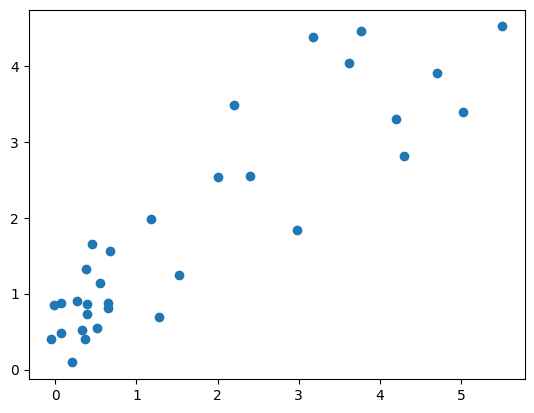

In [77]:
plt.scatter(est, true)